<a href="https://colab.research.google.com/github/VictorMagadi/Code_Alpha_Tasks/blob/main/A_B_test_e_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A/B testing analysis using a realistic e-commerce conversion scenario.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency
import warnings
warnings.filterwarnings('ignore')


In [3]:
# STEP 1: GENERATE REALISTIC A/B TEST DATA #
# Scenario: E-commerce website testing a new checkout UI
# Control (A): Original checkout - 12% conversion rate
# Variant (B): New simplified checkout - 14.5% conversion rate

n_control = 5000      # Users in control group
n_variant = 5000      # Users in variant group
p_control = 0.12      # 12% baseline conversion
p_variant = 0.145     # 14.5% expected lift (+20.8% relative lift)


In [5]:
# Generate binary conversion data (1 = converted, 0 = not converted)
control_conversions = np.random.binomial(1, p_control, n_control)
variant_conversions = np.random.binomial(1, p_variant, n_variant)


In [6]:
# Create DataFrame
df_control = pd.DataFrame({
    'group': 'Control (A)',
    'converted': control_conversions
})

df_variant = pd.DataFrame({
    'group': 'Variant (B)',
    'converted': variant_conversions
})

df = pd.concat([df_control, df_variant], ignore_index=True)


print("A/B TESTING ANALYSIS: E-COMMERCE CHECKOUT UI OPTIMIZATION")

print(f"\n Dataset Overview:")
print(f"   • Total Users: {len(df):,}")
print(f"   • Control Group (A): {n_control:,} users")
print(f"   • Variant Group (B): {n_variant:,} users")
print(f"\n{'Group':<15} {'Users':>10} {'Conversions':>12} {'Rate':>10}")
print("-" * 50)

summary = df.groupby('group')['converted'].agg(['count', 'sum', 'mean']).reset_index()
summary.columns = ['Group', 'Total_Users', 'Conversions', 'Conversion_Rate']
for _, row in summary.iterrows():
    print(f"{row['Group']:<15} {row['Total_Users']:>10,} {row['Conversions']:>12,} {row['Conversion_Rate']:>9.2%}")

A/B TESTING ANALYSIS: E-COMMERCE CHECKOUT UI OPTIMIZATION

 Dataset Overview:
   • Total Users: 10,000
   • Control Group (A): 5,000 users
   • Variant Group (B): 5,000 users

Group                Users  Conversions       Rate
--------------------------------------------------
Control (A)          5,000          651    13.02%
Variant (B)          5,000          744    14.88%


In [7]:
# STEP 2: CALCULATE KEY METRICS #
control_data = df[df['group'] == 'Control (A)']['converted']
variant_data = df[df['group'] == 'Variant (B)']['converted']

n_A = len(control_data)
n_B = len(variant_data)
x_A = control_data.sum()      # conversions in control
x_B = variant_data.sum()      # conversions in variant
p_A = x_A / n_A               # control conversion rate
p_B = x_B / n_B               # variant conversion rate

In [8]:
# Relative lift
relative_lift = (p_B - p_A) / p_A
absolute_lift = p_B - p_A


print("KEY METRICS")

print(f"\n   Control Conversion Rate (p̂_A):  {p_A:.4f} ({p_A:.2%})")
print(f"   Variant Conversion Rate (p̂_B):  {p_B:.4f} ({p_B:.2%})")
print(f"\n   Absolute Lift:                  {absolute_lift:+.4f} ({absolute_lift:+.2%})")
print(f"   Relative Lift:                  {relative_lift:+.2%}")

KEY METRICS

   Control Conversion Rate (p̂_A):  0.1302 (13.02%)
   Variant Conversion Rate (p̂_B):  0.1488 (14.88%)

   Absolute Lift:                  +0.0186 (+1.86%)
   Relative Lift:                  +14.29%


In [11]:
# STEP 3: STATISTICAL TESTING #

print(" STATISTICAL TESTING")
# --- 3.1 Two-Proportion Z-Test ---
print("\n   [1] TWO-PROPORTION Z-TEST (Recommended for large samples)")
print("   " + "-" * 55)

# Pooled proportion
p_pooled = (x_A + x_B) / (n_A + n_B)

# Standard error under null hypothesis
se_null = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))

# Z-statistic
z_stat = (p_B - p_A) / se_null

# Two-tailed p-value
p_value_z = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"   H₀: p_A = p_B  (no difference)")
print(f"   H₁: p_A ≠ p_B  (two-tailed)")
print(f"\n   Pooled Proportion (p̂):          {p_pooled:.4f}")
print(f"   Standard Error (SE):            {se_null:.6f}")
print(f"   Z-Statistic:                    {z_stat:.4f}")
print(f"   P-Value:                        {p_value_z:.6f}")

# Critical values
alpha = 0.05
z_critical = norm.ppf(1 - alpha/2)
print(f"\n   At α = {alpha}:")
print(f"   Critical Z-values:              ±{z_critical:.4f}")
if abs(z_stat) > z_critical:
    print(f" |Z| = {abs(z_stat):.4f} > {z_critical:.4f} → REJECT H₀")
else:
    print(f" |Z| = {abs(z_stat):.4f} ≤ {z_critical:.4f} → FAIL TO REJECT H₀")

# --- 3.2 Chi-Square Test ---
print("\n\n   [2] CHI-SQUARE TEST OF INDEPENDENCE")
print("   " + "-" * 55)

# Contingency table
contingency = np.array([
    [x_A, n_A - x_A],   # [converted, not converted] for Control
    [x_B, n_B - x_B]    # [converted, not converted] for Variant
])

chi2, p_value_chi2, dof, expected = chi2_contingency(contingency)

print(f"   Contingency Table:")
print(f"   {'':>12} {'Converted':>12} {'Not Converted':>14} {'Total':>10}")
print(f"   {'Control (A)':>12} {contingency[0,0]:>12,} {contingency[0,1]:>14,} {n_A:>10,}")
print(f"   {'Variant (B)':>12} {contingency[1,0]:>12,} {contingency[1,1]:>14,} {n_B:>10,}")
print(f"\n   Expected Frequencies:")
print(f"   {'Control (A)':>12} {expected[0,0]:>12.1f} {expected[0,1]:>14.1f}")
print(f"   {'Variant (B)':>12} {expected[1,0]:>12.1f} {expected[1,1]:>14.1f}")
print(f"\n   Chi-Square Statistic (χ²):      {chi2:.4f}")
print(f"   Degrees of Freedom:             {dof}")
print(f"   P-Value:                        {p_value_chi2:.6f}")

# --- 3.3 Welch's T-Test (for continuous-like binary data) ---
print("\n\n   [3] WELCH'S T-TEST (Two-Sample, Unequal Variance)")
print("   " + "-" * 55)

t_stat, p_value_t = stats.ttest_ind(variant_data, control_data, equal_var=False)
print(f"   H₀: µ_A = µ_B")
print(f"   H₁: µ_A ≠ µ_B")
print(f"\n   T-Statistic:                    {t_stat:.4f}")
print(f"   P-Value:                        {p_value_t:.6f}")

 STATISTICAL TESTING

   [1] TWO-PROPORTION Z-TEST (Recommended for large samples)
   -------------------------------------------------------
   H₀: p_A = p_B  (no difference)
   H₁: p_A ≠ p_B  (two-tailed)

   Pooled Proportion (p̂):          0.1395
   Standard Error (SE):            0.006929
   Z-Statistic:                    2.6842
   P-Value:                        0.007270

   At α = 0.05:
   Critical Z-values:              ±1.9600
 |Z| = 2.6842 > 1.9600 → REJECT H₀


   [2] CHI-SQUARE TEST OF INDEPENDENCE
   -------------------------------------------------------
   Contingency Table:
                   Converted  Not Converted      Total
    Control (A)          651          4,349      5,000
    Variant (B)          744          4,256      5,000

   Expected Frequencies:
    Control (A)        697.5         4302.5
    Variant (B)        697.5         4302.5

   Chi-Square Statistic (χ²):      7.0510
   Degrees of Freedom:             1
   P-Value:                        0.007922

In [13]:
# STEP 4: CONFIDENCE INTERVALS

print(" CONFIDENCE INTERVALS")

# --- 4.1 Individual Proportion CIs ---
print("\n   [1] 95% CONFIDENCE INTERVALS FOR INDIVIDUAL RATES")
print("   " + "-" * 55)

def proportion_ci(x, n, confidence=0.95):
    """Wilson Score Interval (more accurate for edge cases)"""
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = x / n
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denominator
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denominator
    return (centre - margin, centre + margin)

ci_A = proportion_ci(x_A, n_A)
ci_B = proportion_ci(x_B, n_B)

print(f"   Control Rate CI:    [{ci_A[0]:.4f}, {ci_A[1]:.4f}]  →  [{ci_A[0]:.2%}, {ci_A[1]:.2%}]")
print(f"   Variant Rate CI:    [{ci_B[0]:.4f}, {ci_B[1]:.4f}]  →  [{ci_B[0]:.2%}, {ci_B[1]:.2%}]")

# --- 4.2 Difference in Proportions CI ---
print("\n\n   [2] 95% CI FOR DIFFERENCE IN PROPORTIONS (p̂_B - p̂_A)")
print("   " + "-" * 55)

# Standard error for difference (unpooled)
se_diff = np.sqrt(p_A*(1-p_A)/n_A + p_B*(1-p_B)/n_B)
margin_diff = z_critical * se_diff
diff_ci_lower = (p_B - p_A) - margin_diff
diff_ci_upper = (p_B - p_A) + margin_diff

print(f"   Point Estimate (p̂_B - p̂_A):     {p_B - p_A:+.4f} ({p_B - p_A:+.2%})")
print(f"   Standard Error:                 {se_diff:.6f}")
print(f"   Margin of Error:                ±{margin_diff:.4f} (±{margin_diff:.2%})")
print(f"\n   95% CI for Difference:          [{diff_ci_lower:+.4f}, {diff_ci_upper:+.4f}]")
print(f"                                   [{diff_ci_lower:+.2%}, {diff_ci_upper:+.2%}]")

if diff_ci_lower > 0:
    print(f"\n   Entire CI is above 0 → Variant is significantly better")
elif diff_ci_upper < 0:
    print(f"\n  Entire CI is below 0 → Control is significantly better")
else:
    print(f"\n  CI includes 0 → No significant difference detected")

# --- 4.3 Relative Risk CI ---
print("\n\n   [3] 95% CI FOR RELATIVE RISK (RR = p̂_B / p̂_A)")
print("   " + "-" * 55)

rr = p_B / p_A
log_rr = np.log(rr)
se_log_rr = np.sqrt((1 - p_A)/(n_A * p_A) + (1 - p_B)/(n_B * p_B))
ci_rr_lower = np.exp(log_rr - z_critical * se_log_rr)
ci_rr_upper = np.exp(log_rr + z_critical * se_log_rr)

print(f"   Relative Risk (RR):             {rr:.4f}")
print(f"   95% CI for RR:                  [{ci_rr_lower:.4f}, {ci_rr_upper:.4f}]")
print(f"   Interpretation:                 Variant is {rr:.2f}x as likely to convert")

# --- 4.4 Number Needed to Treat (NNT) ---
print("\n\n   [4] NUMBER NEEDED TO TREAT (NNT)")
print("   " + "-" * 55)

nnt = 1 / absolute_lift if absolute_lift != 0 else float('inf')
print(f"   NNT = 1 / |p̂_B - p̂_A| = {nnt:.1f}")
print(f"   → Need to expose ~{int(np.ceil(nnt))} users to the new UI")
print(f"     to gain 1 additional conversion")

 CONFIDENCE INTERVALS

   [1] 95% CONFIDENCE INTERVALS FOR INDIVIDUAL RATES
   -------------------------------------------------------
   Control Rate CI:    [0.1212, 0.1398]  →  [12.12%, 13.98%]
   Variant Rate CI:    [0.1392, 0.1589]  →  [13.92%, 15.89%]


   [2] 95% CI FOR DIFFERENCE IN PROPORTIONS (p̂_B - p̂_A)
   -------------------------------------------------------
   Point Estimate (p̂_B - p̂_A):     +0.0186 (+1.86%)
   Standard Error:                 0.006927
   Margin of Error:                ±0.0136 (±1.36%)

   95% CI for Difference:          [+0.0050, +0.0322]
                                   [+0.50%, +3.22%]

   Entire CI is above 0 → Variant is significantly better


   [3] 95% CI FOR RELATIVE RISK (RR = p̂_B / p̂_A)
   -------------------------------------------------------
   Relative Risk (RR):             1.1429
   95% CI for RR:                  [1.0366, 1.2600]
   Interpretation:                 Variant is 1.14x as likely to convert


   [4] NUMBER NEEDED TO TRE

In [14]:
# STEP 5: POWER ANALYSIS & MINIMUM DETECTABLE EFFECT

print("POWER ANALYSIS")

from scipy.stats import norm as norm_dist

def calculate_power(n_per_group, p1, p2, alpha=0.05):
    """Calculate statistical power for two-proportion test"""
    p_pooled = (p1 + p2) / 2
    se_null = np.sqrt(2 * p_pooled * (1 - p_pooled) / n_per_group)
    se_alt = np.sqrt(p1*(1-p1)/n_per_group + p2*(1-p2)/n_per_group)

    z_alpha = norm_dist.ppf(1 - alpha/2)
    z_beta = (abs(p2 - p1) - z_alpha * se_null) / se_alt
    power = norm_dist.cdf(z_beta)
    return power

def sample_size_for_power(p1, p2, power=0.80, alpha=0.05):
    """Calculate required sample size per group"""
    z_alpha = norm_dist.ppf(1 - alpha/2)
    z_beta = norm_dist.ppf(power)
    p_pooled = (p1 + p2) / 2

    n = ((z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
          z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) / abs(p2 - p1)) ** 2
    return int(np.ceil(n))

# Current test power
observed_power = calculate_power(n_A, p_A, p_B, alpha=0.05)

print(f"\n   [1] POST-HOC POWER (Observed Effect)")
print("   " + "-" * 55)
print(f"   Observed Control Rate:          {p_A:.4f}")
print(f"   Observed Variant Rate:          {p_B:.4f}")
print(f"   Sample Size (per group):        {n_A:,}")
print(f"   Achieved Power:                 {observed_power:.2%}")
print(f"   → With {n_A:,} users per group, we had {observed_power:.1%} probability")
print(f"     of detecting this effect if it truly exists")

# Required sample size for 80% and 90% power
n_80 = sample_size_for_power(p_A, p_B, power=0.80, alpha=0.05)
n_90 = sample_size_for_power(p_A, p_B, power=0.90, alpha=0.05)

print(f"\n\n   [2] REQUIRED SAMPLE SIZE (for future tests)")
print("   " + "-" * 55)
print(f"   For 80% Power at α = 0.05:      {n_80:,} per group  ({n_80*2:,} total)")
print(f"   For 90% Power at α = 0.05:      {n_90:,} per group  ({n_90*2:,} total)")

# Minimum Detectable Effect at current sample size
print(f"\n\n   [3] MINIMUM DETECTABLE EFFECT (MDE) at 80% Power")
print("   " + "-" * 55)

def solve_mde(n, p1, power=0.80, alpha=0.05):
    """Find minimum detectable absolute difference"""
    z_alpha = norm_dist.ppf(1 - alpha/2)
    z_beta = norm_dist.ppf(power)

    # Iterative solution
    for mde in np.linspace(0.001, 0.20, 1000):
        p2 = p1 + mde
        p_pooled = (p1 + p2) / 2
        se_null = np.sqrt(2 * p_pooled * (1 - p_pooled) / n)
        se_alt = np.sqrt(p1*(1-p1)/n + p2*(1-p2)/n)
        z_beta_calc = (mde - z_alpha * se_null) / se_alt
        if norm_dist.cdf(z_beta_calc) >= power:
            return mde
    return None

mde = solve_mde(n_A, p_A, power=0.80, alpha=0.05)
mde_relative = mde / p_A

print(f"   With {n_A:,} users per group:")
print(f"   Absolute MDE:                   ±{mde:.4f} (±{mde:.2%})")
print(f"   Relative MDE:                   ±{mde_relative:.2%}")
print(f"   → We can reliably detect differences ≥ {mde:.2%} absolute")

POWER ANALYSIS

   [1] POST-HOC POWER (Observed Effect)
   -------------------------------------------------------
   Observed Control Rate:          0.1302
   Observed Variant Rate:          0.1488
   Sample Size (per group):        5,000
   Achieved Power:                 76.56%
   → With 5,000 users per group, we had 76.6% probability
     of detecting this effect if it truly exists


   [2] REQUIRED SAMPLE SIZE (for future tests)
   -------------------------------------------------------
   For 80% Power at α = 0.05:      5,446 per group  (10,892 total)
   For 90% Power at α = 0.05:      7,290 per group  (14,580 total)


   [3] MINIMUM DETECTABLE EFFECT (MDE) at 80% Power
   -------------------------------------------------------
   With 5,000 users per group:
   Absolute MDE:                   ±0.0195 (±1.95%)
   Relative MDE:                   ±15.00%
   → We can reliably detect differences ≥ 1.95% absolute


In [15]:
# STEP 6: BUSINESS IMPACT & ROI CALCULATION

print(" BUSINESS IMPACT & ROI PROJECTION")

# Business assumptions
monthly_traffic = 100000      # Monthly visitors
avg_order_value = 85          # Average order value in USD
cost_of_new_ui = 15000        # Development & deployment cost

# Projected monthly impact
monthly_control_conversions = monthly_traffic * p_A
monthly_variant_conversions = monthly_traffic * p_B
additional_conversions = monthly_variant_conversions - monthly_control_conversions
additional_revenue = additional_conversions * avg_order_value

# Annual projection
annual_additional_revenue = additional_revenue * 12
roi = (annual_additional_revenue - cost_of_new_ui) / cost_of_new_ui * 100

print(f"\n   Assumptions:")
print(f"   • Monthly Traffic:              {monthly_traffic:,} users")
print(f"   • Average Order Value:          ${avg_order_value:,.2f}")
print(f"   • Implementation Cost:          ${cost_of_new_ui:,.2f}")

print(f"\n   Monthly Impact Projection:")
print(f"   • Control Conversions:          {monthly_control_conversions:,.0f}")
print(f"   • Variant Conversions:          {monthly_variant_conversions:,.0f}")
print(f"   • Additional Conversions:       +{additional_conversions:,.0f} (+{additional_conversions/monthly_control_conversions:.1%})")
print(f"   • Additional Monthly Revenue:   +${additional_revenue:,.2f}")

print(f"\n   Annual Projection:")
print(f"   • Additional Annual Revenue:    +${annual_additional_revenue:,.2f}")
print(f"   • Implementation Cost:          ${cost_of_new_ui:,.2f}")
print(f"   • Net Annual Benefit:           ${annual_additional_revenue - cost_of_new_ui:,.2f}")
print(f"   • ROI (1st Year):               {roi:.0f}%")
print(f"   • Payback Period:               ~{max(1, int(cost_of_new_ui / additional_revenue))} month(s)")

 BUSINESS IMPACT & ROI PROJECTION

   Assumptions:
   • Monthly Traffic:              100,000 users
   • Average Order Value:          $85.00
   • Implementation Cost:          $15,000.00

   Monthly Impact Projection:
   • Control Conversions:          13,020
   • Variant Conversions:          14,880
   • Additional Conversions:       +1,860 (+14.3%)
   • Additional Monthly Revenue:   +$158,100.00

   Annual Projection:
   • Additional Annual Revenue:    +$1,897,200.00
   • Implementation Cost:          $15,000.00
   • Net Annual Benefit:           $1,882,200.00
   • ROI (1st Year):               12548%
   • Payback Period:               ~1 month(s)


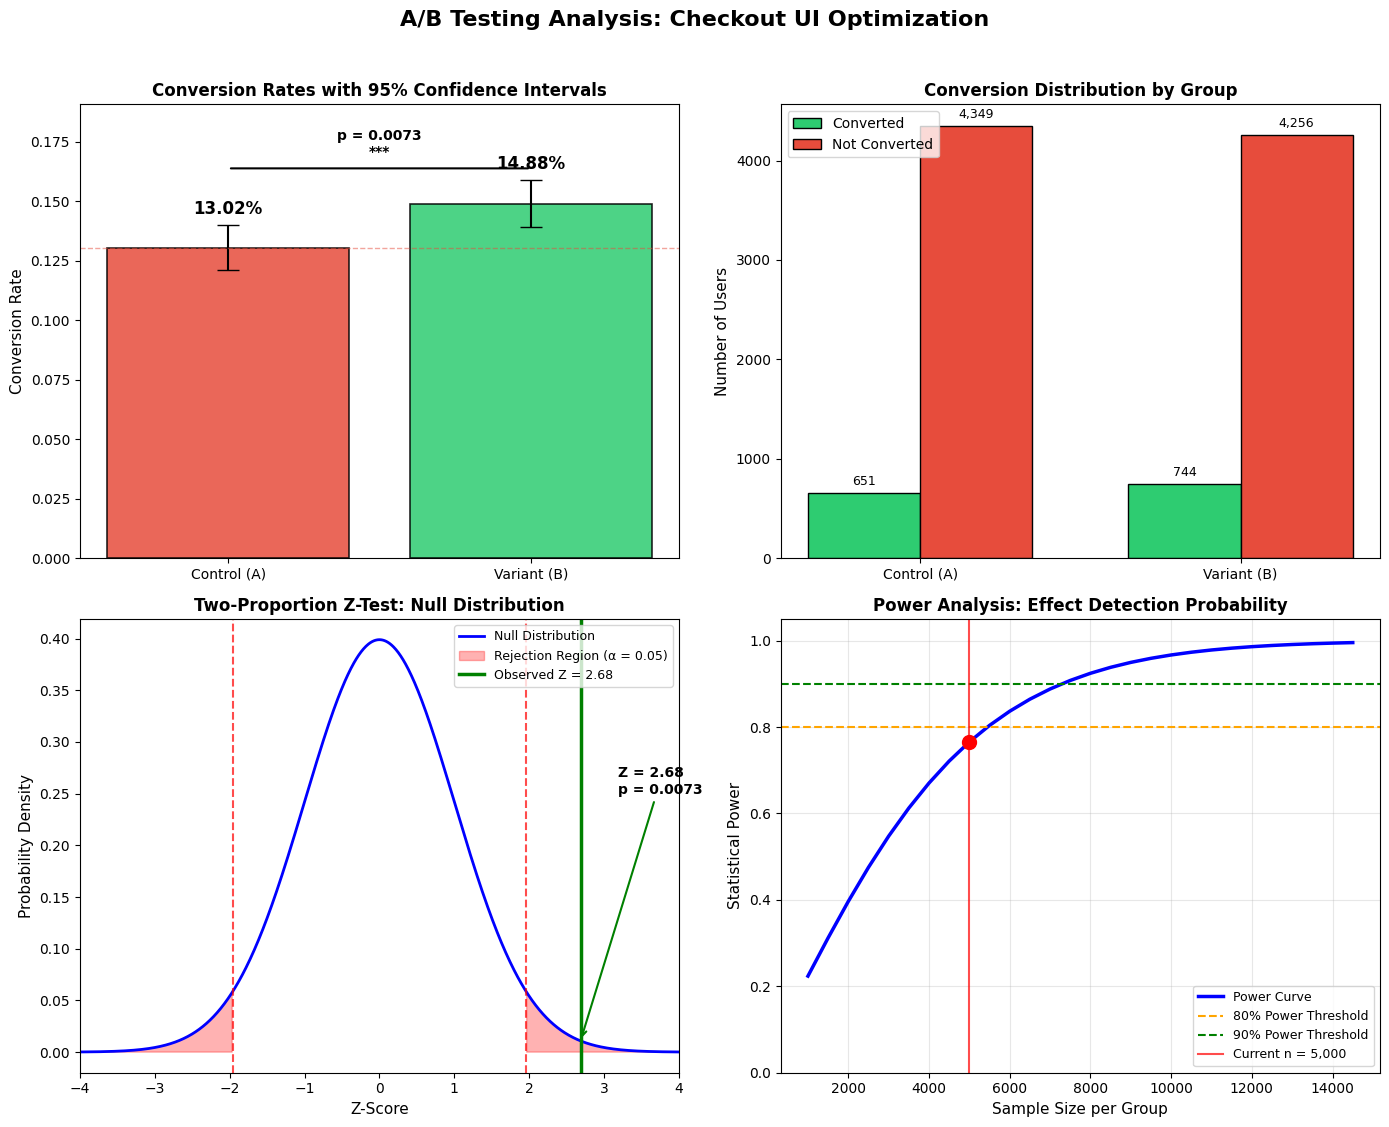


 Visualization saved successfully!


In [17]:
# STEP 7: VISUALIZATIONS

import os

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('A/B Testing Analysis: Checkout UI Optimization', fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Conversion Rates with Error Bars ---
ax1 = axes[0, 0]
groups = ['Control (A)', 'Variant (B)']
rates = [p_A, p_B]
ci_low = [ci_A[0], ci_B[0]]
ci_high = [ci_A[1], ci_B[1]]
errors = [[rates[i] - ci_low[i] for i in range(2)], [ci_high[i] - rates[i] for i in range(2)]]

colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(groups, rates, yerr=errors, capsize=8, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)
ax1.set_ylabel('Conversion Rate', fontsize=11)
ax1.set_title('Conversion Rates with 95% Confidence Intervals', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(ci_high) * 1.2)
ax1.axhline(y=p_A, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)

for i, (bar, rate) in enumerate(zip(bars, rates)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + errors[1][i] + 0.003,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add significance indicator
ax1.annotate('', xy=(1, max(rates) + 0.015), xytext=(0, max(rates) + 0.015),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
ax1.text(0.5, max(rates) + 0.02, f'p = {p_value_z:.4f}\n***', ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Distribution of Conversions ---
ax2 = axes[0, 1]
conversion_counts = [x_A, x_B]
not_converted = [n_A - x_A, n_B - x_B]
x_pos = np.arange(len(groups))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, conversion_counts, width, label='Converted', color='#2ecc71', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, not_converted, width, label='Not Converted', color='#e74c3c', edgecolor='black')

ax2.set_ylabel('Number of Users', fontsize=11)
ax2.set_title('Conversion Distribution by Group', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 50, f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

# --- Plot 3: Z-Test Visualization ---
ax3 = axes[1, 0]
x_z = np.linspace(-4, 4, 1000)
y_z = norm_dist.pdf(x_z, 0, 1)
ax3.plot(x_z, y_z, 'b-', linewidth=2, label='Null Distribution')
ax3.fill_between(x_z, y_z, where=(x_z <= -z_critical) | (x_z >= z_critical),
                 alpha=0.3, color='red', label='Rejection Region (α = 0.05)')
ax3.axvline(z_stat, color='green', linestyle='-', linewidth=2.5, label=f'Observed Z = {z_stat:.2f}')
ax3.axvline(-z_critical, color='red', linestyle='--', alpha=0.7)
ax3.axvline(z_critical, color='red', linestyle='--', alpha=0.7)

ax3.set_xlabel('Z-Score', fontsize=11)
ax3.set_ylabel('Probability Density', fontsize=11)
ax3.set_title('Two-Proportion Z-Test: Null Distribution', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.set_xlim(-4, 4)
ax3.annotate(f'Z = {z_stat:.2f}\np = {p_value_z:.4f}', xy=(z_stat, norm_dist.pdf(z_stat, 0, 1)),
            xytext=(z_stat + 0.5, 0.25), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# --- Plot 4: Power Curve ---
ax4 = axes[1, 1]
sample_sizes = np.arange(1000, 15000, 500)
powers = [calculate_power(n, p_A, p_B, alpha=0.05) for n in sample_sizes]

ax4.plot(sample_sizes, powers, 'b-', linewidth=2.5, label='Power Curve')
ax4.axhline(0.80, color='orange', linestyle='--', linewidth=1.5, label='80% Power Threshold')
ax4.axhline(0.90, color='green', linestyle='--', linewidth=1.5, label='90% Power Threshold')
ax4.axvline(n_A, color='red', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Current n = {n_A:,}')
ax4.scatter([n_A], [observed_power], color='red', s=100, zorder=5)

ax4.set_xlabel('Sample Size per Group', fontsize=11)
ax4.set_ylabel('Statistical Power', fontsize=11)
ax4.set_title('Power Analysis: Effect Detection Probability', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1.05)
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Ensure the directory exists before saving
os.makedirs('/mnt/agents/output/', exist_ok=True)
plt.savefig('/mnt/agents/output/ab_testing_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\n Visualization saved successfully!")

## A/B Test Results Dashboard

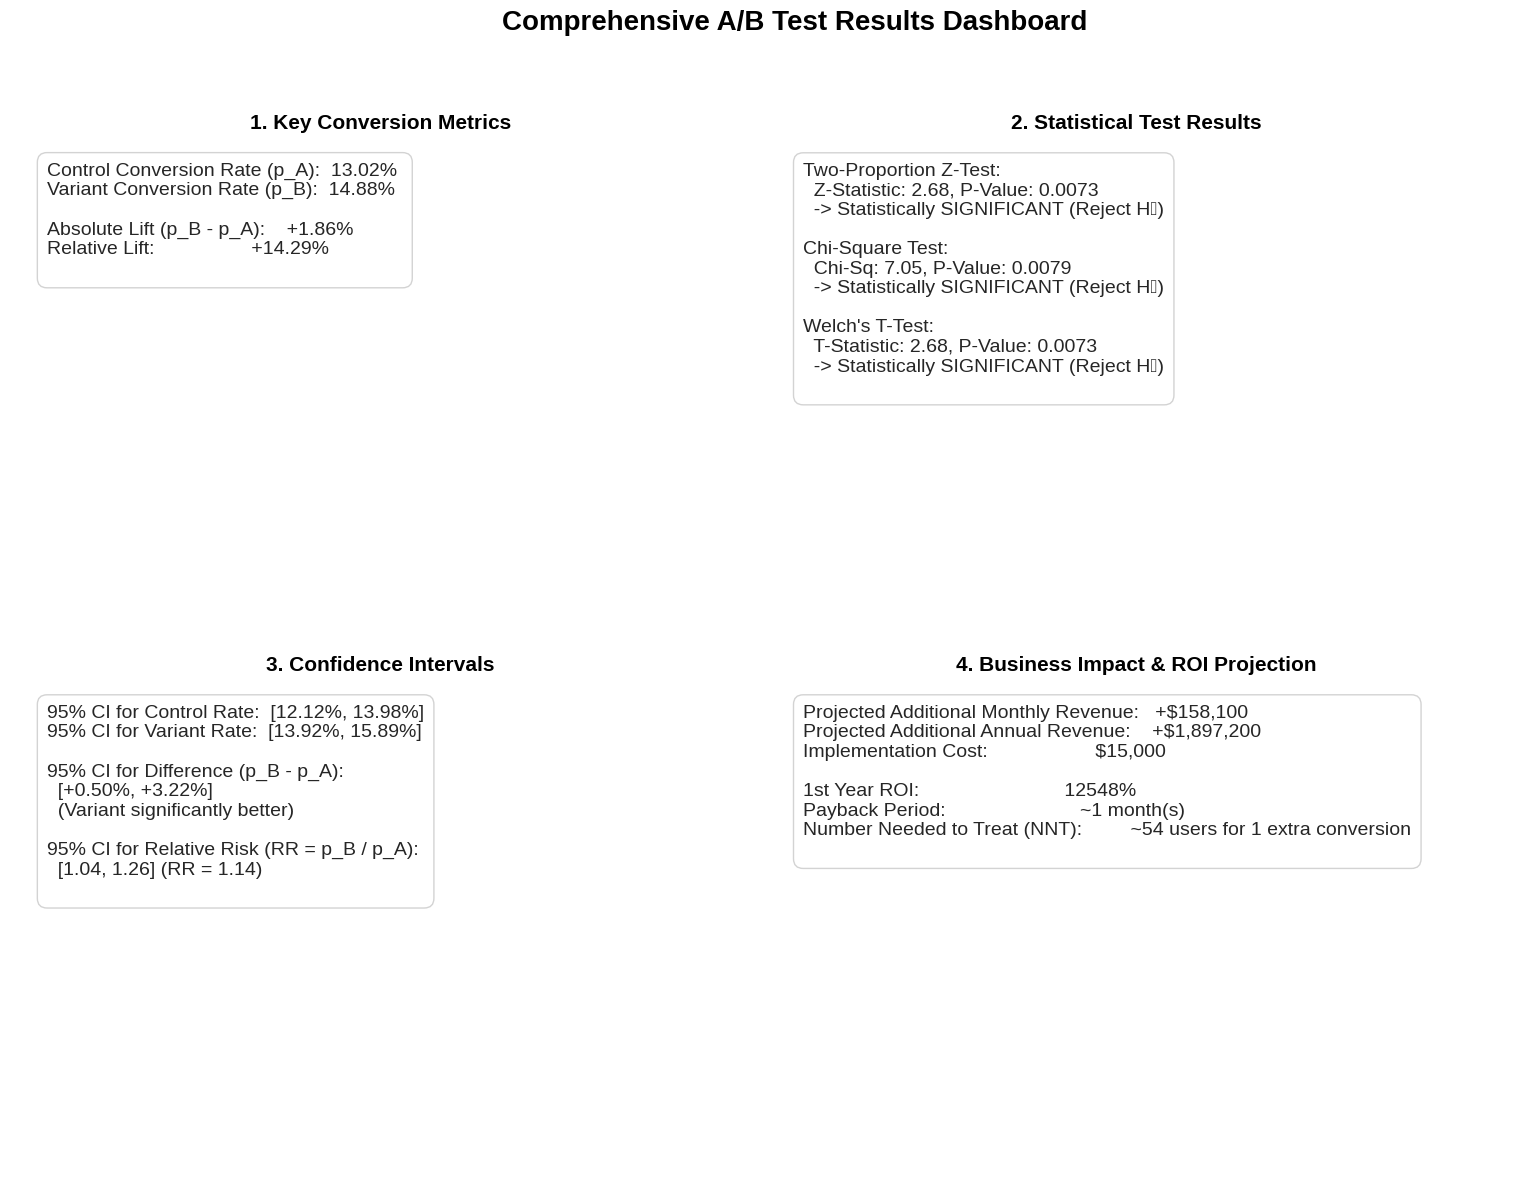


A/B Test Dashboard generated and saved as 'ab_test_dashboard.png'!


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive A/B Test Results Dashboard', fontsize=20, fontweight='bold', y=1.02)
plt.style.use('seaborn-v0_8-darkgrid')

# --- Panel 1: Key Metrics ---
ax1 = axes[0, 0]
ax1.set_title('1. Key Conversion Metrics', fontsize=15, fontweight='bold')
ax1.axis('off')

metrics_text = f""
metrics_text += f"Control Conversion Rate (p_A):  {p_A:.2%} \n"
metrics_text += f"Variant Conversion Rate (p_B):  {p_B:.2%} \n\n"
metrics_text += f"Absolute Lift (p_B - p_A):    {absolute_lift:+.2%} \n"
metrics_text += f"Relative Lift:                  {relative_lift:+.2%} \n"

ax1.text(0.05, 0.95, metrics_text, transform=ax1.transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='lightgray', lw=1))

# --- Panel 2: Statistical Significance ---
ax2 = axes[0, 1]
ax2.set_title('2. Statistical Test Results', fontsize=15, fontweight='bold')
ax2.axis('off')

stats_text = f""
stats_text += f"Two-Proportion Z-Test:\n"
stats_text += f"  Z-Statistic: {z_stat:.2f}, P-Value: {p_value_z:.4f}\n"
if abs(z_stat) > z_critical: # Use z_critical from earlier step
    stats_text += f"  -> Statistically SIGNIFICANT (Reject H₀)\n\n"
else:
    stats_text += f"  -> NOT Statistically Significant (Fail to Reject H₀)\n\n"

stats_text += f"Chi-Square Test:\n"
stats_text += f"  Chi-Sq: {chi2:.2f}, P-Value: {p_value_chi2:.4f}\n"
if p_value_chi2 < alpha: # Use alpha from earlier step
    stats_text += f"  -> Statistically SIGNIFICANT (Reject H₀)\n\n"
else:
    stats_text += f"  -> NOT Statistically Significant (Fail to Reject H₀)\n\n"

stats_text += f"Welch's T-Test:\n"
stats_text += f"  T-Statistic: {t_stat:.2f}, P-Value: {p_value_t:.4f}\n"
if p_value_t < alpha:
    stats_text += f"  -> Statistically SIGNIFICANT (Reject H₀)\n"
else:
    stats_text += f"  -> NOT Statistically Significant (Fail to Reject H₀)\n"

ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='lightgray', lw=1))

# --- Panel 3: Confidence Intervals ---
ax3 = axes[1, 0]
ax3.set_title('3. Confidence Intervals', fontsize=15, fontweight='bold')
ax3.axis('off')

ci_text = f""
ci_text += f"95% CI for Control Rate:  [{ci_A[0]:.2%}, {ci_A[1]:.2%}]\n"
ci_text += f"95% CI for Variant Rate:  [{ci_B[0]:.2%}, {ci_B[1]:.2%}]\n\n"
ci_text += f"95% CI for Difference (p_B - p_A):\n"
ci_text += f"  [{diff_ci_lower:+.2%}, {diff_ci_upper:+.2%}]\n"
if diff_ci_lower > 0: ci_text += f"  (Variant significantly better)\n"
elif diff_ci_upper < 0: ci_text += f"  (Control significantly better)\n"
else: ci_text += f"  (Includes 0 - No significant difference)\n"
ci_text += f"\n95% CI for Relative Risk (RR = p_B / p_A):\n"
ci_text += f"  [{ci_rr_lower:.2f}, {ci_rr_upper:.2f}] (RR = {rr:.2f})\n"

ax3.text(0.05, 0.95, ci_text, transform=ax3.transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='lightgray', lw=1))

# --- Panel 4: Business Impact & ROI ---
ax4 = axes[1, 1]
ax4.set_title('4. Business Impact & ROI Projection', fontsize=15, fontweight='bold')
ax4.axis('off')

business_text = f""
business_text += f"Projected Additional Monthly Revenue:   +${additional_revenue:,.0f}\n"
business_text += f"Projected Additional Annual Revenue:    +${annual_additional_revenue:,.0f}\n"
business_text += f"Implementation Cost:                    ${cost_of_new_ui:,.0f}\n\n"
business_text += f"1st Year ROI:                           {roi:.0f}%\n"
business_text += f"Payback Period:                         ~{max(1, int(cost_of_new_ui / additional_revenue))} month(s)\n"
business_text += f"Number Needed to Treat (NNT):         ~{int(np.ceil(nnt))} users for 1 extra conversion\n"

ax4.text(0.05, 0.95, business_text, transform=ax4.transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='lightgray', lw=1))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap

# Ensure the directory exists before saving
os.makedirs('/mnt/agents/output/', exist_ok=True)
plt.savefig('/mnt/agents/output/ab_test_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\nA/B Test Dashboard generated and saved as 'ab_test_dashboard.png'!")

In [20]:
output_path = '/mnt/agents/output/ab_test_summary.csv'
summary.to_csv(output_path, index=False)
print(f"'summary' DataFrame exported to {output_path}")

'summary' DataFrame exported to /mnt/agents/output/ab_test_summary.csv


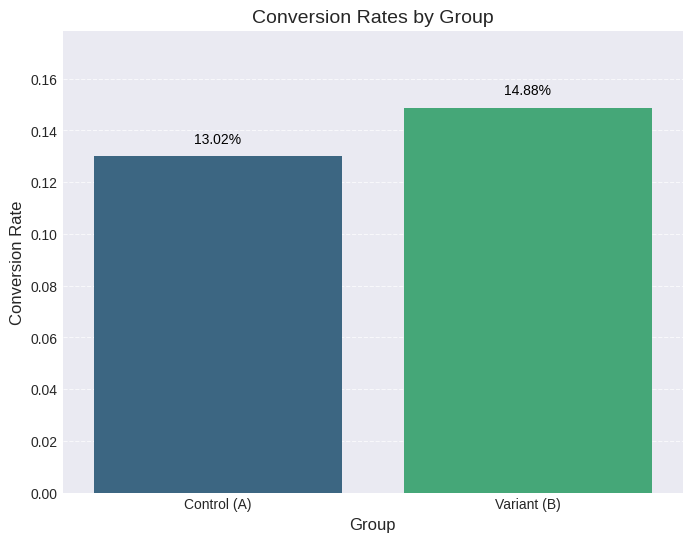

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Group', y='Conversion_Rate', data=summary, palette='viridis')
plt.title('Conversion Rates by Group', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0, max(summary['Conversion_Rate']) * 1.2)

for index, row in summary.iterrows():
    plt.text(index, row['Conversion_Rate'] + 0.005, f'{row['Conversion_Rate']:.2%}', color='black', ha="center", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()